# Model Comparison — USGS Streamflow (+ 1-Day Oracle Rain)

Same GNN architectures as the historical-rain notebook, but the precipitation
covariate now includes **tomorrow's actual rainfall** as a perfect 1-day oracle:
at every input timestep `t`, the model sees `R(t)` (contemporaneous) and
`R(t+1)` (actual rain the following day).

**Why 1 day instead of 3?** Providing the full 3-day oracle increased outlet MAE
while improving peak timing — the model over-amplified distant future rain signals.
The 1-day lead is more physically grounded: tomorrow's rain is the direct driver
of tomorrow's outlet flow via the last routing hop.

| Model | Temporal encoder | Spatial encoder |
|---|---|---|
| **DCRNN** | GRU | Diffusion convolution (ChebNet) |
| **GRUGCNModel** | GRU | Graph convolution (GCN) |

Settings: `window=7` days in → `horizon=3` days out, 31 gauges, daily discharge.


## How this notebook works

### Exogenous covariate `u` — 2-channel oracle rain

For each sample predicting days `t+1 … t+3`, the covariate `u` has shape
`(B, window, N, 2)`.  At the last step of the input window (day `t`):

| Channel | Content at last input step |
|---------|---------------------------|
| 0 | `R(t)` — contemporaneous rain (same as historical notebook) |
| 1 | `R(t+1)` — 1-day-ahead oracle (actual next-day rain) |

### Train / Val / Test split — by time, not by gauge

```
|─────── train (70%) ──────|── val (10%) ──|── test (20%) ──|
Oct 2021                                   Jul 19, 2022    Sep 30, 2022
```


## 1. Data setup


In [12]:
import os
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl
from tsl.data import SpatioTemporalDataset, SpatioTemporalDataModule, TemporalSplitter
from tsl.data.preprocessing import StandardScaler
from tsl.engines import Predictor
from tsl.metrics.torch import MaskedMAE, MaskedMSE

pl.seed_everything(42)

WINDOW  = 7
HORIZON = 3
BATCH   = 16

DATA_DIR      = os.path.abspath(os.path.join(os.getcwd(), '../../data/clean/'))
FORECASTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/forecast/'))

# --- Target: streamflow ---
streamflow = pd.read_csv(
    os.path.join(DATA_DIR, 'streamflow_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)

id_conversion = pd.read_csv(
    os.path.join(os.getcwd(), '../02_Generate_Graph_And_Data_Analysis/site_id_naming_reference.csv'),
    dtype={'site_id': str}
)
rename_map = id_conversion.set_index('site_id')['site_rename'].to_dict()

target = streamflow.rename(columns=rename_map)
target = target[sorted(target.columns, key=lambda x: int(x.replace('site', '')))]
target = target.ffill().bfill()

# --- Precipitation ---
precipitation = pd.read_csv(
    os.path.join(DATA_DIR, 'precipitation_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)
precipitation = precipitation.rename(columns=rename_map)
precipitation = precipitation[sorted(precipitation.columns, key=lambda x: int(x.replace('site', '')))]
precipitation = precipitation.ffill().bfill()

common_idx    = target.index.intersection(precipitation.index)
target        = target.loc[common_idx]
precipitation = precipitation.loc[common_idx]
print(f'Aligned to {len(common_idx)} shared timesteps')

# --- Oracle rain covariate: current + HORIZON lead days ---
# For sample at time t, channel k contains R(t - window + 1 + k_offset ... t + k),
# so at the LAST step of the input window the model sees R(t), R(t+1), R(t+2), R(t+3).
# bfill() fills the NaN rows created by negative shifts at the end of the series.
rain_np = np.stack(
    [precipitation.shift(-k).bfill().values for k in range(2)],
    axis=2,
)  # (T, N, HORIZON+1) = (T, N, 4)
precip_tensor = torch.tensor(rain_np, dtype=torch.float32)
print(f'1-day oracle rain tensor: {tuple(precip_tensor.shape)}  — (T, N, 2 leads)')
print(f'  channel 0: R(t)     — contemporaneous')
print(f'  channel 1: R(t+1)   — 1-day oracle  ← only lead day')

N_NODES = target.shape[1]
print(f'\nTarget: {target.shape}')

# --- Connectivity ---
graph_edges_all = [
    ('site0','site2'),('site1','site2'),('site2','site6'),('site3','site6'),
    ('site4','site6'),('site5','site6'),('site6','site8'),('site7','site8'),
    ('site8','site9'),('site9','site11'),('site10','site11'),('site11','site13'),
    ('site12','site13'),('site13','site15'),('site14','site15'),('site15','site17'),
    ('site16','site17'),('site18','site21'),('site19','site20'),('site20','site21'),
    ('site21','site26'),('site22','site26'),('site23','site26'),('site24','site26'),
    ('site25','site26'),('site26','site27'),('site27','site30'),('site28','site29'),
    ('site29','site30'),('site30','site13'),
]
node_to_idx = {f'site{i}': i for i in range(31)}
src = [node_to_idx[u] for u, v in graph_edges_all]
dst = [node_to_idx[v] for u, v in graph_edges_all]
edge_index  = torch.tensor([src, dst], dtype=torch.long)
edge_weight = torch.ones(edge_index.shape[1], dtype=torch.float)
connectivity = (edge_index, edge_weight)
print(f'Graph: {N_NODES} nodes, {edge_index.shape[1]} edges')


Seed set to 42


Aligned to 364 shared timesteps
1-day oracle rain tensor: (364, 31, 2)  — (T, N, 2 leads)
  channel 0: R(t)     — contemporaneous
  channel 1: R(t+1)   — 1-day oracle  ← only lead day

Target: (364, 31)
Graph: 31 nodes, 30 edges


## 2. Shared dataset and datamodule factory


In [13]:
EXOG_SIZE = 2   # 2 channels: R(t) contemporaneous + R(t+1) 1-day oracle

torch_dataset = SpatioTemporalDataset(
    target=target,
    connectivity=connectivity,
    window=WINDOW,
    horizon=HORIZON,
    stride=1,
)
torch_dataset.add_covariate('u', precip_tensor, pattern='t n f')

def make_dm():
    """Fresh DataModule with refitted scalers — call once per model run."""
    dm = SpatioTemporalDataModule(
        dataset=torch_dataset,
        scalers={
            'target': StandardScaler(axis=(0, 1)),
            'u':      StandardScaler(axis=(0, 1)),
        },
        splitter=TemporalSplitter(val_len=0.1, test_len=0.2),
        batch_size=BATCH,
        workers=4,
    )
    dm.setup()
    return dm

dm_check = make_dm()
batch = next(iter(dm_check.train_dataloader()))
print('Sample input x :', batch.input.x.shape)   # (B, window, N, 1)
print('Sample input u :', batch.input.u.shape)   # (B, window, N, 2)  — 1-day oracle rain
print('Sample target y:', batch.y.shape)          # (B, horizon, N, 1)
print('Train / Val / Test batches:',
      len(dm_check.train_dataloader()),
      len(dm_check.val_dataloader()),
      len(dm_check.test_dataloader()))


Sample input x : torch.Size([16, 7, 31, 1])
Sample input u : torch.Size([16, 7, 31, 2])
Sample target y: torch.Size([16, 3, 31, 1])
Train / Val / Test batches: 15 2 5


## 3. Training helper + forecast collection


In [14]:
from pytorch_lightning.callbacks import ModelCheckpoint

def train_and_evaluate(model, name, max_epochs=30):
    print(f'\n{"="*60}')
    print(f'  {name}')
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable parameters: {n_params:,}')
    print(f'{"="*60}')

    dm = make_dm()

    predictor = Predictor(
        model=model,
        optim_class=torch.optim.Adam,
        optim_kwargs={'lr': 1e-3},
        loss_fn=MaskedMAE(),
        metrics={'mae': MaskedMAE(), 'mse': MaskedMSE()},
        scale_target=True,
    )

    checkpoint_cb = ModelCheckpoint(
        monitor='val_mae',
        mode='min',
        save_top_k=1,
        filename=f'{name}-rain-forecast-best',
    )

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator='auto',
        devices=1,
        enable_progress_bar=True,
        logger=False,
        callbacks=[checkpoint_cb],
    )

    trainer.fit(predictor, datamodule=dm)

    predictor = Predictor.load_from_checkpoint(
        checkpoint_cb.best_model_path,
        model=model,
        optim_class=torch.optim.Adam,
        optim_kwargs={'lr': 1e-3},
        loss_fn=MaskedMAE(),
        metrics={'mae': MaskedMAE(), 'mse': MaskedMSE()},
        scale_target=True,
        weights_only=False,
    )

    test_metrics = trainer.test(predictor, datamodule=dm, verbose=False)

    predictor.eval()
    y_true_list, y_hat_list = [], []
    with torch.no_grad():
        for batch in dm.test_dataloader():
            y_hat = predictor.predict_batch(batch, preprocess=False, postprocess=False)
            y_true_list.append(batch.y.cpu())
            y_hat_list.append(y_hat.cpu())

    y_true_all = torch.cat(y_true_list).squeeze(-1)
    y_hat_all  = torch.cat(y_hat_list).squeeze(-1)

    scaler = dm.scalers['target']
    n, h, n_nodes = y_true_all.shape
    y_true_inv = y_true_all.numpy()
    y_hat_inv  = scaler.inverse_transform(
        y_hat_all.reshape(-1, n_nodes)).reshape(n, h, n_nodes).numpy()

    test_indices = dm.test_dataloader().dataset.indices
    pred_dates   = target.index[[idx + WINDOW for idx in test_indices]]

    forecasts = {
        'y_true'  : y_true_inv[:, 0, :],
        'y_hat'   : y_hat_inv[:, 0, :],
        'y_true_h': y_true_inv,
        'y_hat_h' : y_hat_inv,
        'dates'   : pred_dates,
        'dm'      : dm,
    }

    test_metrics[0]['model']    = name
    test_metrics[0]['n_params'] = n_params
    return test_metrics[0], forecasts


## 4. Model A — DCRNN
Same architecture as before but `exog_size=4` to accept the 4-channel oracle rain.


In [15]:
from tsl.nn.models import DCRNNModel

dcrnn = DCRNNModel(
    input_size=1,
    exog_size=EXOG_SIZE,
    output_size=1,
    horizon=HORIZON,
    hidden_size=32,
    kernel_size=8,
    n_layers=2,
    dropout=0.1,
)

results_dcrnn, forecasts_dcrnn = train_and_evaluate(dcrnn, 'DCRNN')
save_path = os.path.join(FORECASTS_DIR, 'dcrnn_forecasts_rain_forecast_1day.pt')
torch.save(forecasts_dcrnn, save_path)
print(f'Saved to: {save_path}')


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



  DCRNN
  Trainable parameters: 220,547


/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/mfleury/Documents/Classes/CEE520 Network Science-Graph Learning/CEE520-StreamflowGraphLearning/src/03_TorchSpatiotemporal/checkpoints exists and is not empty.

  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss_fn       | MaskedMAE        | 0      | train | 0    
1 | train_metrics | MetricCollection | 0      | train | 0    
2 | val_metrics   | MetricCollection | 0      | train | 0    
3 | test_metrics  | MetricCollection | 0      | train | 0    
4 | model         | DCRNNModel       | 220 K  | train | 0    
-------------------------------------------------------------------
220 K     Trainable params
0         Non-trainable params
220 K     Total params
0.882     Total estimated model params size (MB)
49        Modules in train mode
0         Modules in eval mode
0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


...

Testing DataLoader 0:   0%|          | 0/5 [00:00<?, ?it/s]

Only args ['u', 'edge_weight', 'x', 'edge_index'] are forwarded to the model (DCRNNModel).


Testing DataLoader 0:  20%|██        | 1/5 [00:00<00:01,  2.81it/s]

/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Testing DataLoader 0: 100%|██████████| 5/5 [00:01<00:00,  4.32it/s]
Saved to: /Users/mfleury/Documents/Classes/CEE520 Network Science-Graph Learning/CEE520-StreamflowGraphLearning/data/forecast/dcrnn_forecasts_rain_forecast_1day.pt


## 5. Model B — GRUGCNModel
Same architecture as before but `exog_size=4` to accept the 4-channel oracle rain.


In [16]:
from tsl.nn.models import GRUGCNModel

grugcn = GRUGCNModel(
    input_size=1,
    hidden_size=32,
    output_size=1,
    horizon=HORIZON,
    exog_size=EXOG_SIZE,
    enc_layers=2,
    gcn_layers=8,
)

results_grugcn, forecasts_grugcn = train_and_evaluate(grugcn, 'GRUGCNModel')
save_path = os.path.join(FORECASTS_DIR, 'grugcn_forecasts_rain_forecast_1day.pt')
torch.save(forecasts_grugcn, save_path)
print(f'Saved to: {save_path}')


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/mfleury/Documents/Classes/CEE520 Network Science-Graph Learning/CEE520-StreamflowGraphLearning/src/03_TorchSpatiotemporal/checkpoints exists and is not empty.

  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss_fn       | MaskedMAE        | 0      | train | 0    
1 | train_metrics | MetricCollection | 0      | train | 0    
2 | val_metrics   | MetricCollection | 0      | train | 0    
3 | test_metrics  | MetricCollection | 0      | train | 0    
4 | model      


  GRUGCNModel
  Trainable parameters: 20,547
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

Only args ['u', 'edge_weight', 'x', 'edge_index'] are forwarded to the model (GRUGCNModel).


...

Testing DataLoader 0:   0%|          | 0/5 [00:00<?, ?it/s]

Only args ['u', 'edge_weight', 'x', 'edge_index'] are forwarded to the model (GRUGCNModel).


Testing DataLoader 0:  80%|████████  | 4/5 [00:00<00:00, 21.73it/s]

/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Testing DataLoader 0: 100%|██████████| 5/5 [00:00<00:00, 22.34it/s]
Saved to: /Users/mfleury/Documents/Classes/CEE520 Network Science-Graph Learning/CEE520-StreamflowGraphLearning/data/forecast/grugcn_forecasts_rain_forecast_1day.pt


## 6. Results comparison


In [17]:
import matplotlib.pyplot as plt
import os, json
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl
from tsl.data import SpatioTemporalDataset, SpatioTemporalDataModule, TemporalSplitter
from tsl.data.preprocessing import StandardScaler
from tsl.engines import Predictor
from tsl.metrics.torch import MaskedMAE, MaskedMSE

pl.seed_everything(42)

DATA_DIR      = os.path.abspath(os.path.join(os.getcwd(), '../../data/clean/'))
FORECASTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/forecast/'))

streamflow = pd.read_csv(
    os.path.join(DATA_DIR, 'streamflow_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)
id_conversion = pd.read_csv(
    os.path.join(os.getcwd(), '../02_Generate_Graph_And_Data_Analysis/site_id_naming_reference.csv'),
    dtype={'site_id': str}
)
rename_map = id_conversion.set_index('site_id')['site_rename'].to_dict()
target = streamflow.rename(columns=rename_map)
target = target[sorted(target.columns, key=lambda x: int(x.replace('site', '')))]
target = target.ffill().bfill()
N_NODES = target.shape[1]

MODEL_FILES = {
    'DCRNN':       'dcrnn_forecasts_rain_forecast_1day.pt',
    'GRUGCNModel': 'grugcn_forecasts_rain_forecast_1day.pt',
}

all_forecasts = {}
all_results   = []

for name, fname in MODEL_FILES.items():
    fpath = os.path.join(FORECASTS_DIR, fname)
    if not os.path.exists(fpath):
        print(f'Missing: {fpath} — run the training cells first')
        continue
    fc = torch.load(fpath, weights_only=False)
    all_forecasts[name] = fc
    mae = float(np.abs(fc['y_true'] - fc['y_hat']).mean())
    mse = float(((fc['y_true'] - fc['y_hat']) ** 2).mean())
    all_results.append({'model': name, 'test_mae': mae, 'test_mse': mse, 'n_params': None})
    print(f'Loaded {name}  MAE={mae:.3f} m³/s  MSE={mse:.3f}')

df_results = pd.DataFrame(all_results).set_index('model')
df_results.columns = [c.replace('test_', '') for c in df_results.columns]
print()
print(df_results[['mae', 'mse', 'n_params']].to_string())


Seed set to 42


Loaded DCRNN  MAE=2.254 m³/s  MSE=36.093
Loaded GRUGCNModel  MAE=2.171 m³/s  MSE=54.860

                  mae        mse n_params
model                                    
DCRNN        2.254105  36.093376     None
GRUGCNModel  2.171182  54.859871     None


/opt/anaconda3/envs/tsl_env/lib/python3.10/site-packages/torch/serialization.py:2190: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  result = unpickler.load()


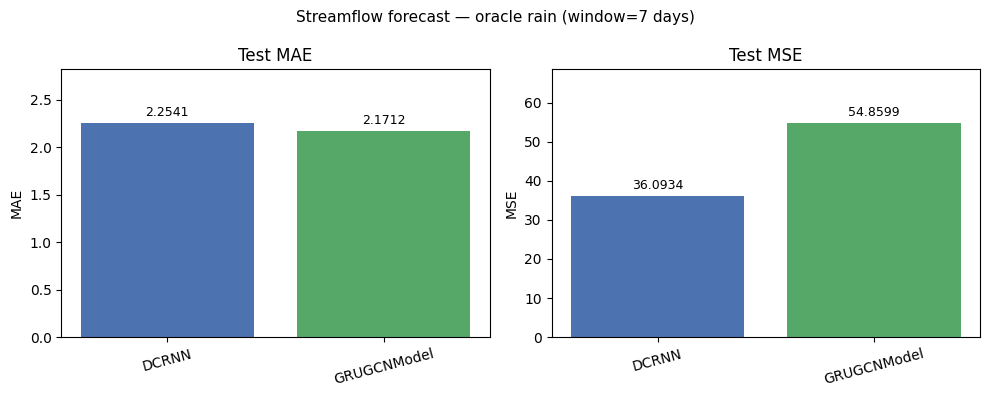

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = df_results.index.tolist()
colors = ['#4C72B0', '#55A868']

for ax, metric in zip(axes, ['mae', 'mse']):
    bars = ax.bar(models, df_results[metric], color=colors)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_title(f'Test {metric.upper()}')
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, df_results[metric].max() * 1.25)

plt.suptitle('Streamflow forecast — oracle rain (window=7 days)', fontsize=11)
plt.tight_layout()
plt.savefig('figures/bar_chart_rain_forecast_1day.png', dpi=300)
plt.show()


## 7. All-gauge forecast plots

- **Grey** — observed discharge 30 days before the test period
- **Black** — observed during the test period
- **Coloured** — model step-1 forecast


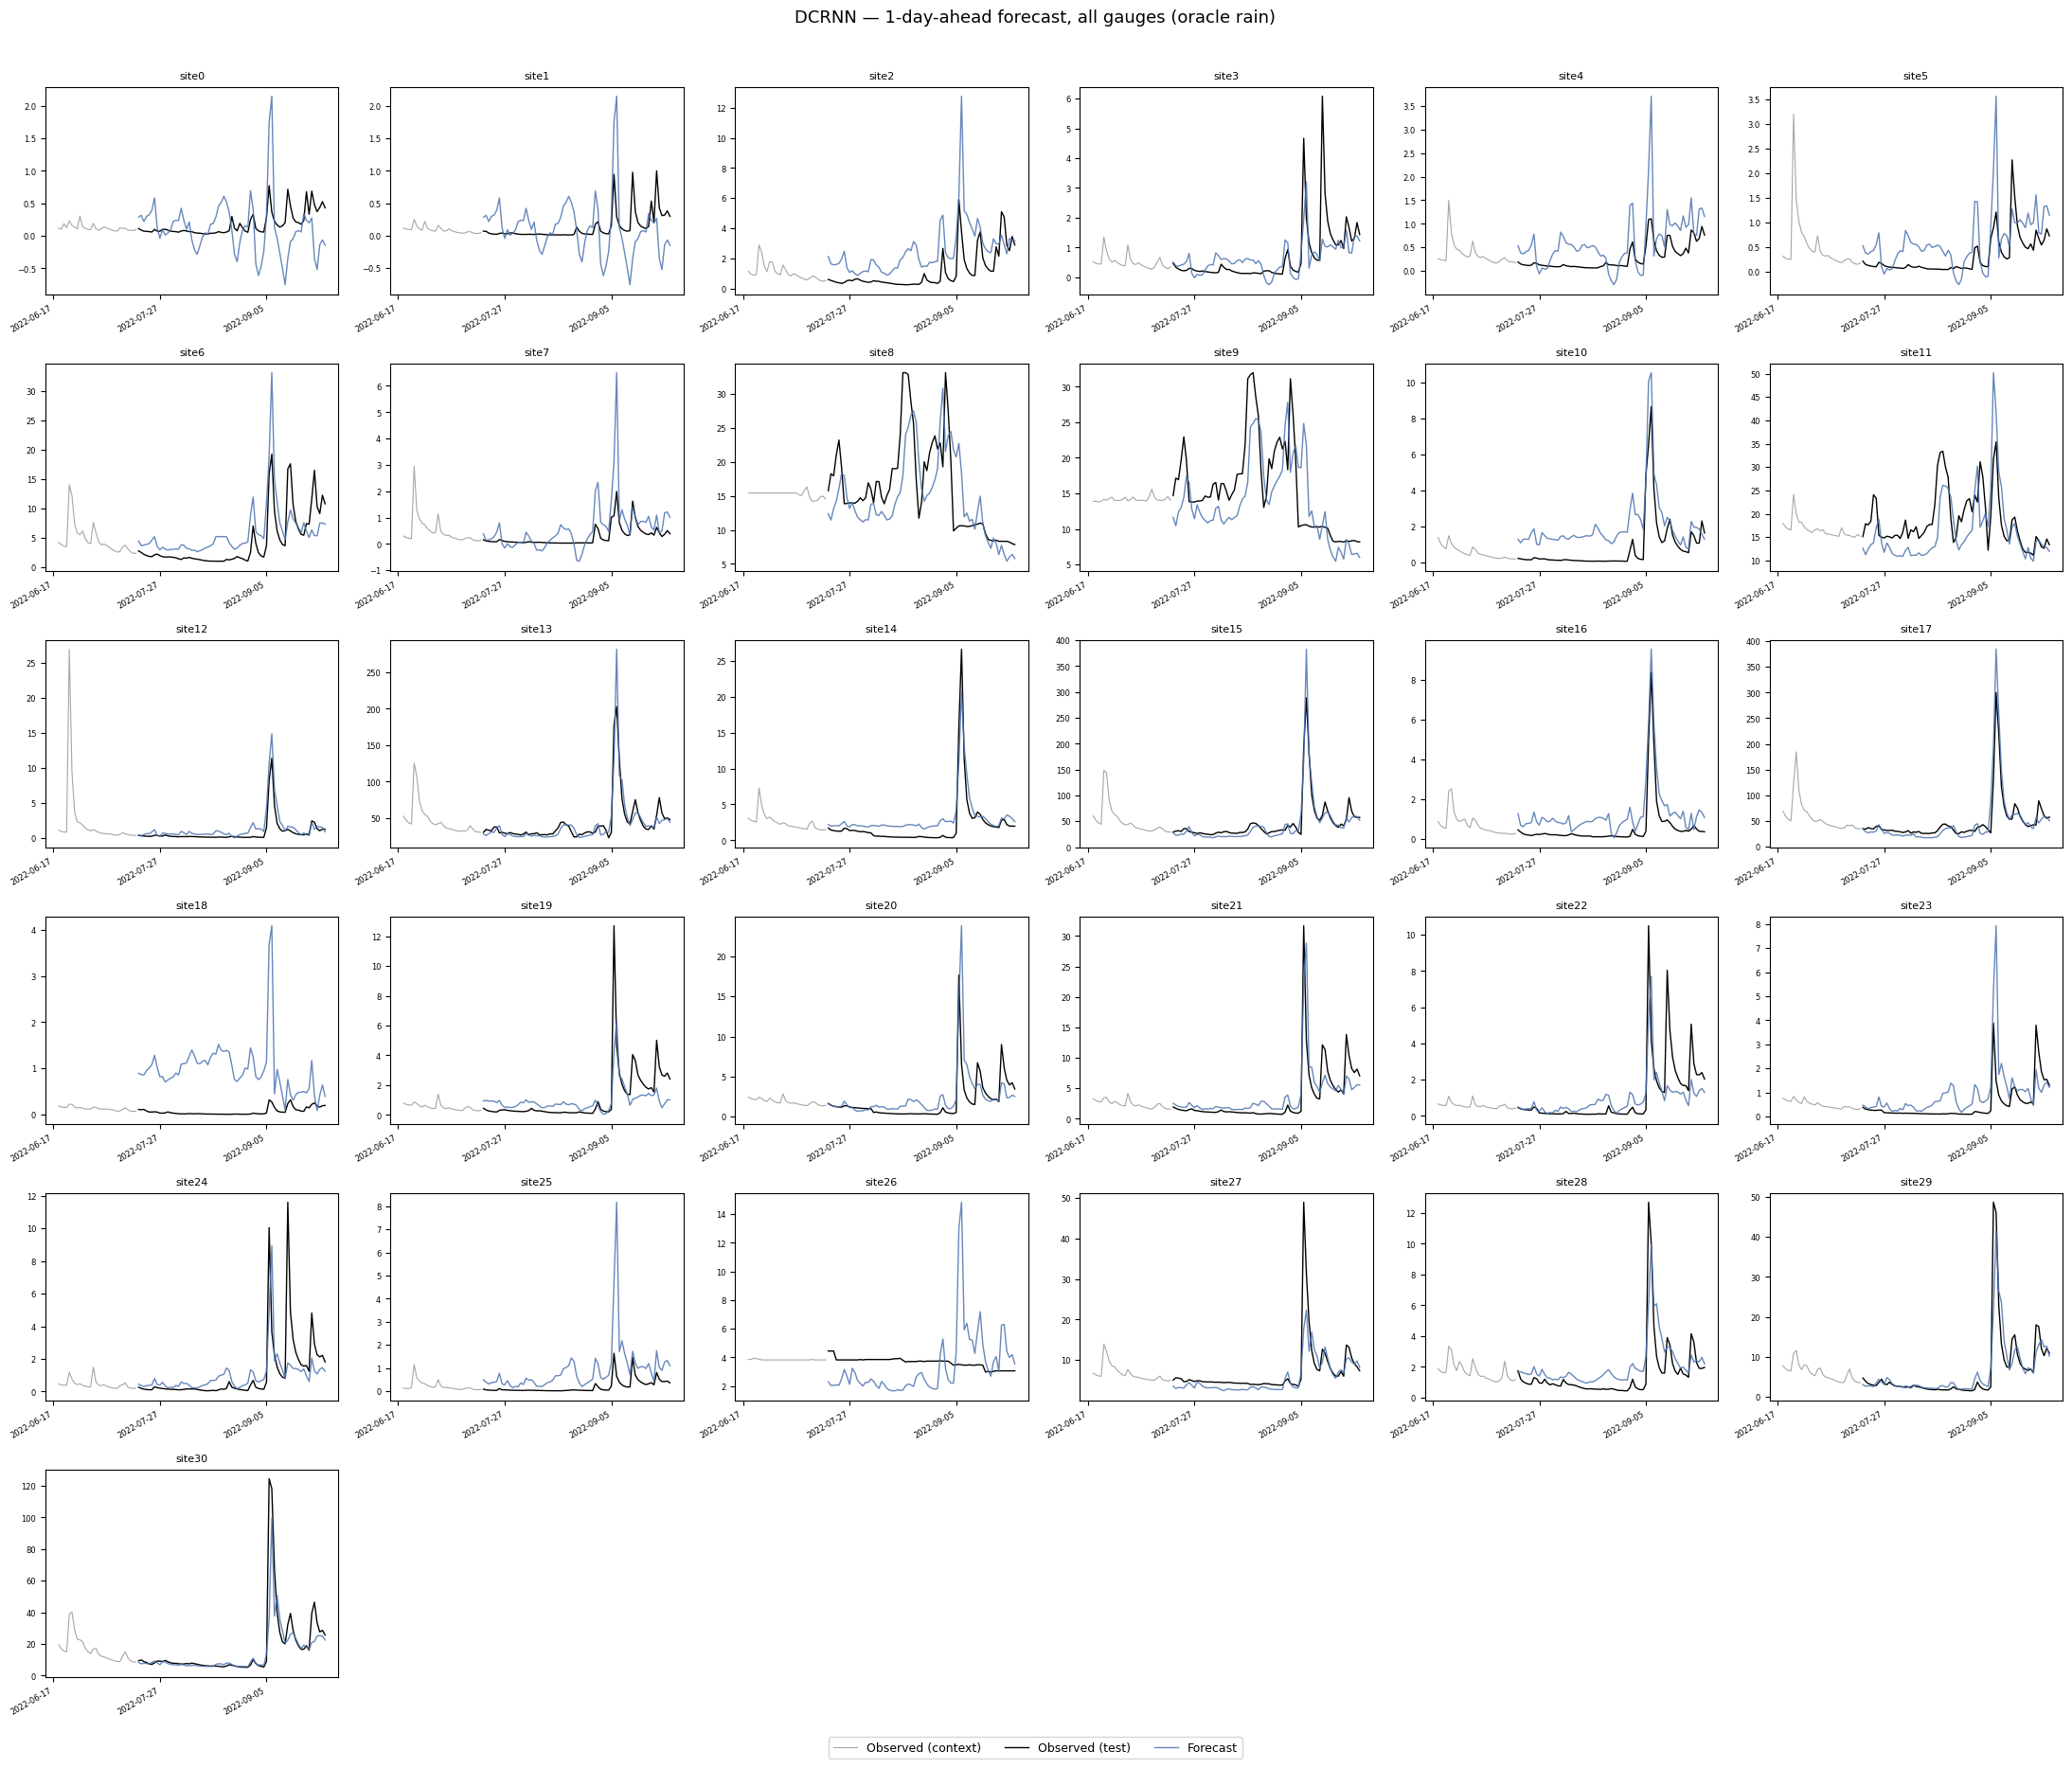

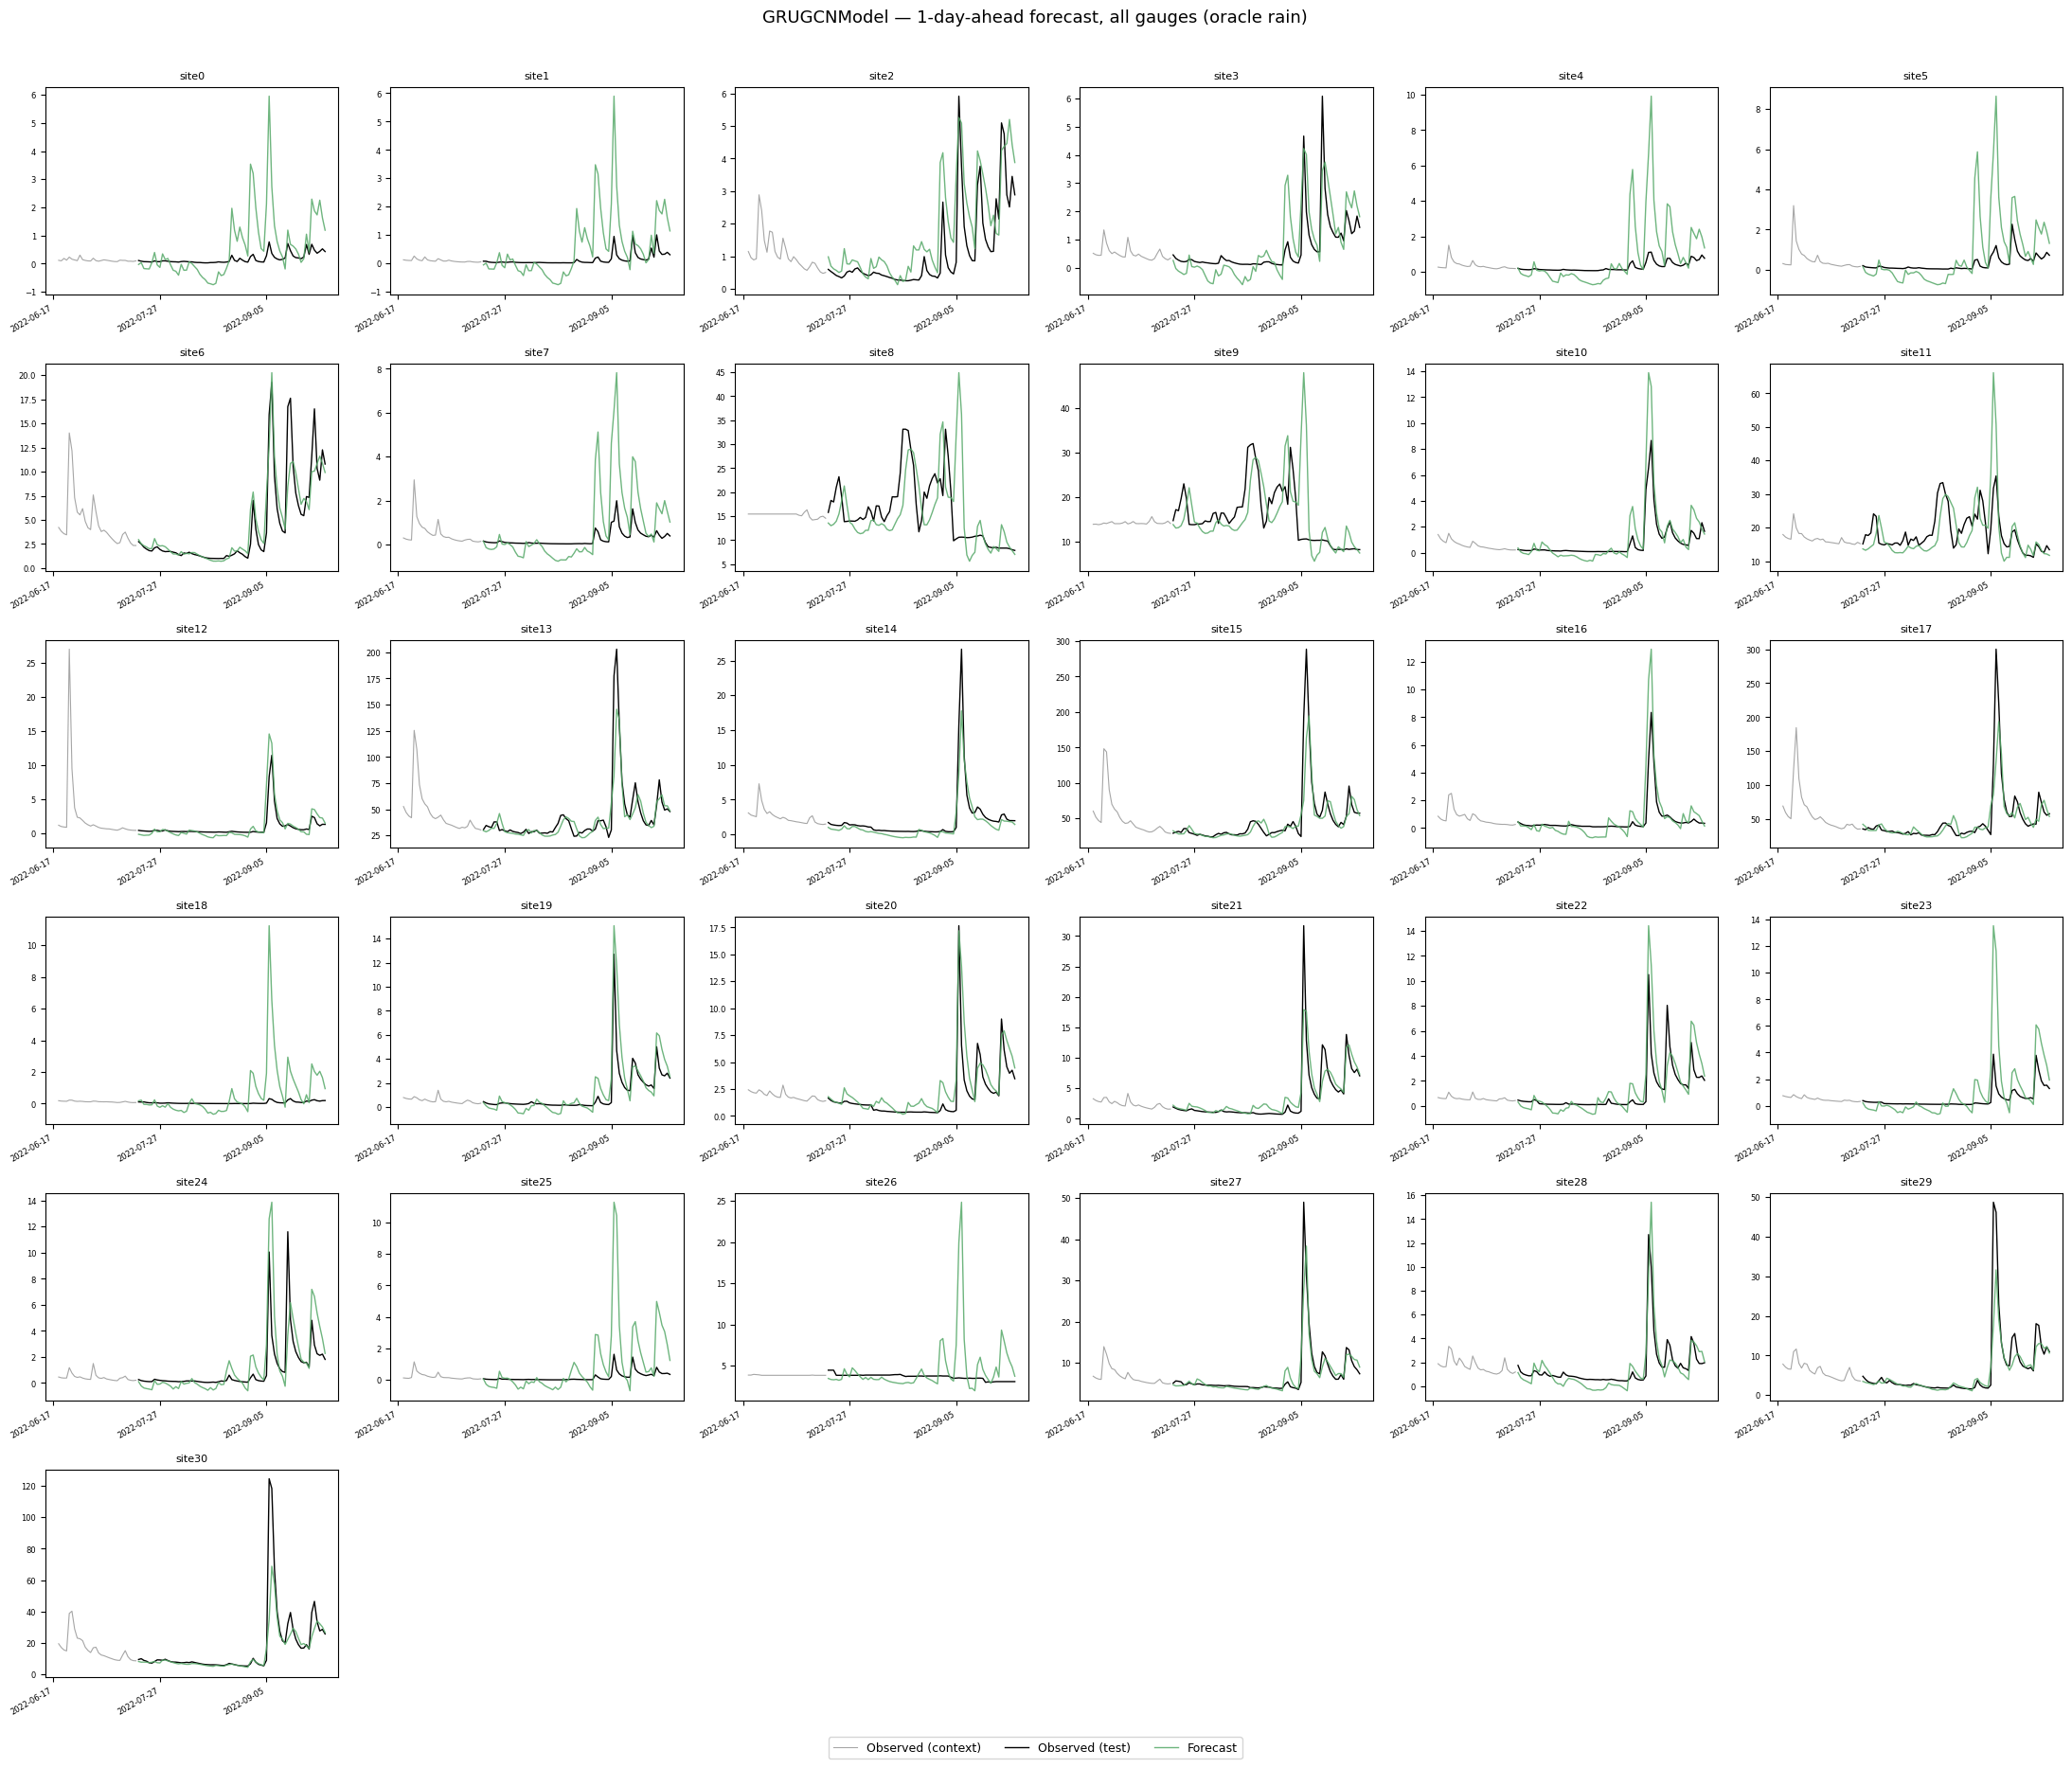

In [19]:
CONTEXT_DAYS = 30
MODEL_COLORS = {'DCRNN': '#4C72B0', 'GRUGCNModel': '#55A868'}
OUTLET_NODE  = 17
OUTLET_NAME  = 'site17 — West Branch Delaware R. at Hobart NY'
CONTEXT_DAYS_OUTLET = 60

def plot_all_gauges(forecasts_dict, context_days=CONTEXT_DAYS):
    node_names = list(target.columns)
    ncols, nrows = 6, 6

    for model_name, fc in forecasts_dict.items():
        dates  = fc['dates']
        y_true = fc['y_true']
        y_hat  = fc['y_hat']

        test_start    = dates[0]
        context_start = test_start - pd.Timedelta(days=context_days)
        context = target.loc[context_start:test_start - pd.Timedelta(days=1)]

        fig, axes = plt.subplots(nrows, ncols, figsize=(22, 18), sharex=False)
        fig.suptitle(f'{model_name} — 1-day-ahead forecast, all gauges (oracle rain)', fontsize=13, y=1.01)

        for idx, ax in enumerate(axes.flat):
            if idx >= N_NODES:
                ax.set_visible(False)
                continue
            ax.plot(context.index, context.iloc[:, idx], color='grey', lw=0.8, alpha=0.7, label='Observed (context)')
            ax.plot(dates, y_true[:, idx], color='black', lw=1.0, label='Observed (test)')
            ax.plot(dates, y_hat[:, idx], color=MODEL_COLORS[model_name], lw=1.0, alpha=0.85, label='Forecast')
            ax.set_title(node_names[idx], fontsize=8)
            ax.tick_params(labelsize=6)
            ax.xaxis.set_major_locator(plt.MaxNLocator(3))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

        handles, labels = axes.flat[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
        plt.tight_layout()
        plt.savefig(f'figures/all_sites_{model_name}_rain_forecast_1day', dpi=300)
        plt.show()

plot_all_gauges(all_forecasts)


## 8. Outlet gauge — all models overlaid

Key question: does the oracle rain reduce the visual routing lag at site17
compared to the historical-rain and no-rain notebooks?


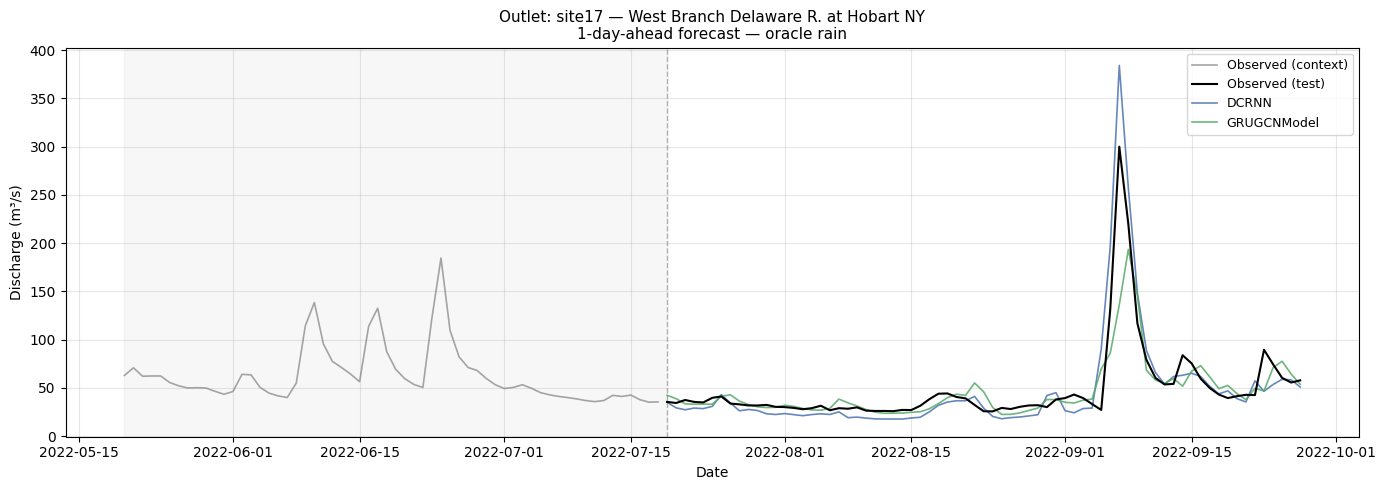

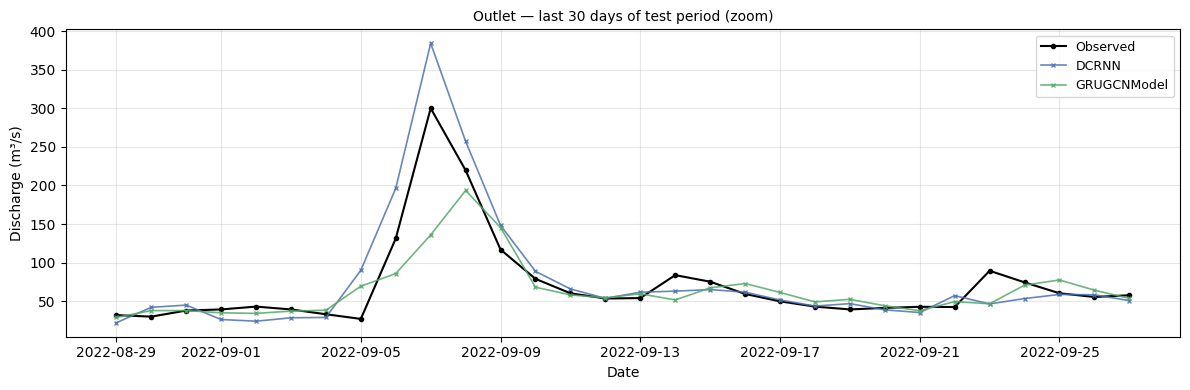

In [20]:
def plot_outlet(forecasts_dict, node_idx=OUTLET_NODE, context_days=CONTEXT_DAYS_OUTLET):
    first_fc   = next(iter(forecasts_dict.values()))
    dates      = first_fc['dates']
    test_start = dates[0]

    context_start = test_start - pd.Timedelta(days=context_days)
    context = target.loc[context_start:test_start - pd.Timedelta(days=1), f'site{node_idx}']

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axvspan(context.index[0], test_start, alpha=0.06, color='grey')
    ax.axvline(test_start, color='grey', lw=1, ls='--', alpha=0.6)
    ax.plot(context.index, context.values, color='grey', lw=1.2, alpha=0.7, label='Observed (context)')
    ax.plot(dates, first_fc['y_true'][:, node_idx], color='black', lw=1.5, label='Observed (test)', zorder=5)

    for model_name, fc in forecasts_dict.items():
        ax.plot(dates, fc['y_hat'][:, node_idx],
                color=MODEL_COLORS[model_name], lw=1.2, alpha=0.85, label=model_name)

    ax.set_title(f'Outlet: {OUTLET_NAME}\n1-day-ahead forecast — oracle rain', fontsize=11)
    ax.set_ylabel('Discharge (m³/s)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/outlet_rain_forecast_1day.png', dpi=300)
    plt.show()

    zoom_start = dates[-30]
    mask = dates >= zoom_start
    fig2, ax2 = plt.subplots(figsize=(12, 4))
    ax2.plot(dates[mask], first_fc['y_true'][mask, node_idx],
             color='black', lw=1.5, marker='o', ms=3, label='Observed')
    for model_name, fc in forecasts_dict.items():
        ax2.plot(dates[mask], fc['y_hat'][mask, node_idx],
                 color=MODEL_COLORS[model_name], lw=1.2, alpha=0.85, marker='x', ms=3, label=model_name)
    ax2.set_title('Outlet — last 30 days of test period (zoom)', fontsize=10)
    ax2.set_ylabel('Discharge (m³/s)')
    ax2.set_xlabel('Date')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/outlet_rain_forecast_zoom.png', dpi=300)
    plt.show()

plot_outlet(all_forecasts)


## 9. Per-site error analysis

Grouped bar chart of per-site MAE (site0 → site30) for each model.
- **Absolute MAE (m³/s)** — top panel
- **Relative MAE (% of mean observed discharge)** — bottom panel

Also prints the persistence diagnostic for the outlet.


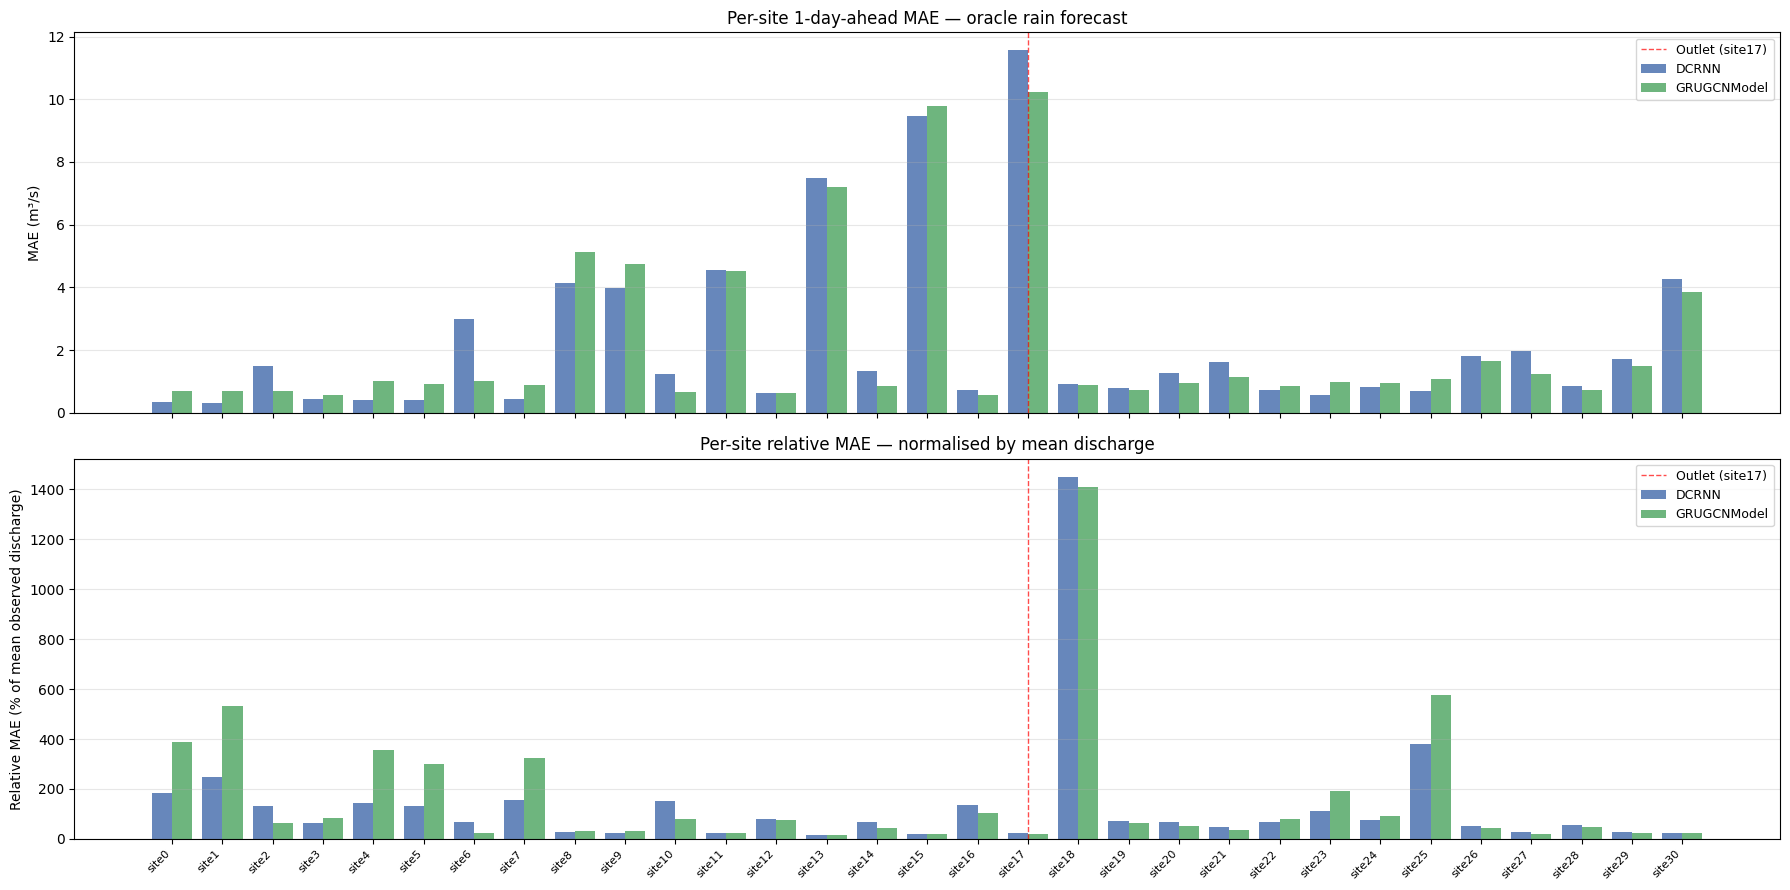

In [21]:
# ── Grouped bar chart ─────────────────────────────────────────────────
site_indices = list(range(N_NODES))
x_labels     = [f'site{n}' for n in site_indices]
n_models     = len(all_forecasts)
bar_width    = 0.8 / n_models
x            = np.arange(N_NODES)

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)

ax1 = axes[0]
for i, (model_name, fc) in enumerate(all_forecasts.items()):
    per_site_mae = np.abs(fc['y_true'] - fc['y_hat']).mean(axis=0)
    offsets = (i - (n_models - 1) / 2) * bar_width
    ax1.bar(x + offsets, per_site_mae[site_indices], width=bar_width,
            label=model_name, color=MODEL_COLORS[model_name], alpha=0.85)

ax1.axvline(OUTLET_NODE, color='red', ls='--', lw=1.0, alpha=0.7, label='Outlet (site17)')
ax1.set_ylabel('MAE (m³/s)')
ax1.set_title('Per-site 1-day-ahead MAE — oracle rain forecast')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
for i, (model_name, fc) in enumerate(all_forecasts.items()):
    per_site_mae  = np.abs(fc['y_true'] - fc['y_hat']).mean(axis=0)
    per_site_mean = fc['y_true'].mean(axis=0).clip(min=0.01)
    per_site_rel  = per_site_mae / per_site_mean * 100
    offsets = (i - (n_models - 1) / 2) * bar_width
    ax2.bar(x + offsets, per_site_rel[site_indices], width=bar_width,
            label=model_name, color=MODEL_COLORS[model_name], alpha=0.85)

ax2.axvline(OUTLET_NODE, color='red', ls='--', lw=1.0, alpha=0.7, label='Outlet (site17)')
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Relative MAE (% of mean observed discharge)')
ax2.set_title('Per-site relative MAE — normalised by mean discharge')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/per_site_mae_rain_forecast_1day.png', dpi=300)
plt.show()


In [22]:
# ── Persistence diagnostic ────────────────────────────────────────────
print('Outlet (site17) — persistence vs model (oracle rain):')
for model_name, fc in all_forecasts.items():
    yt = fc['y_true'][:, OUTLET_NODE]
    yh = fc['y_hat'][:, OUTLET_NODE]
    persist_mae = float(np.abs(np.diff(yt)).mean())
    model_mae   = float(np.abs(yt - yh).mean())
    corr_same   = float(np.corrcoef(yh, yt)[0, 1])
    corr_lag1   = float(np.corrcoef(yh[1:], yt[:-1])[0, 1])
    print(f'  {model_name}: model_MAE={model_mae:.3f}  persist_MAE={persist_mae:.3f}  '
          f'corr(ŷ,y)={corr_same:.3f}  corr(ŷₜ,yₜ₋₁)={corr_lag1:.3f}')

Outlet (site17) — persistence vs model (oracle rain):
  DCRNN: model_MAE=11.555  persist_MAE=11.453  corr(ŷ,y)=0.967  corr(ŷₜ,yₜ₋₁)=0.708
  GRUGCNModel: model_MAE=10.241  persist_MAE=11.453  corr(ŷ,y)=0.851  corr(ŷₜ,yₜ₋₁)=0.921


## 10. Horizon comparison and lagged ensemble at the outlet -- Justification for using 1 day ahead prediction

For each model, plot all three horizon steps at their **target dates** alongside the
lagged ensemble:

| Line | Made using data up to… | Predicts… |
|------|------------------------|----------|
| step-1 | yesterday | today |
| step-2 | two days ago | today |
| step-3 | three days ago | today |
| ensemble | all three averaged | today |

**We see that the prediction based on most recent information is best, and that the "delay" in predicting peaks increases as we predict from further out.**



DCRNN — outlet MAE by horizon (oracle rain):
  step-1:   11.555 m³/s
  step-2:   14.414 m³/s
  step-3:   18.712 m³/s
  ensemble: 12.314 m³/s


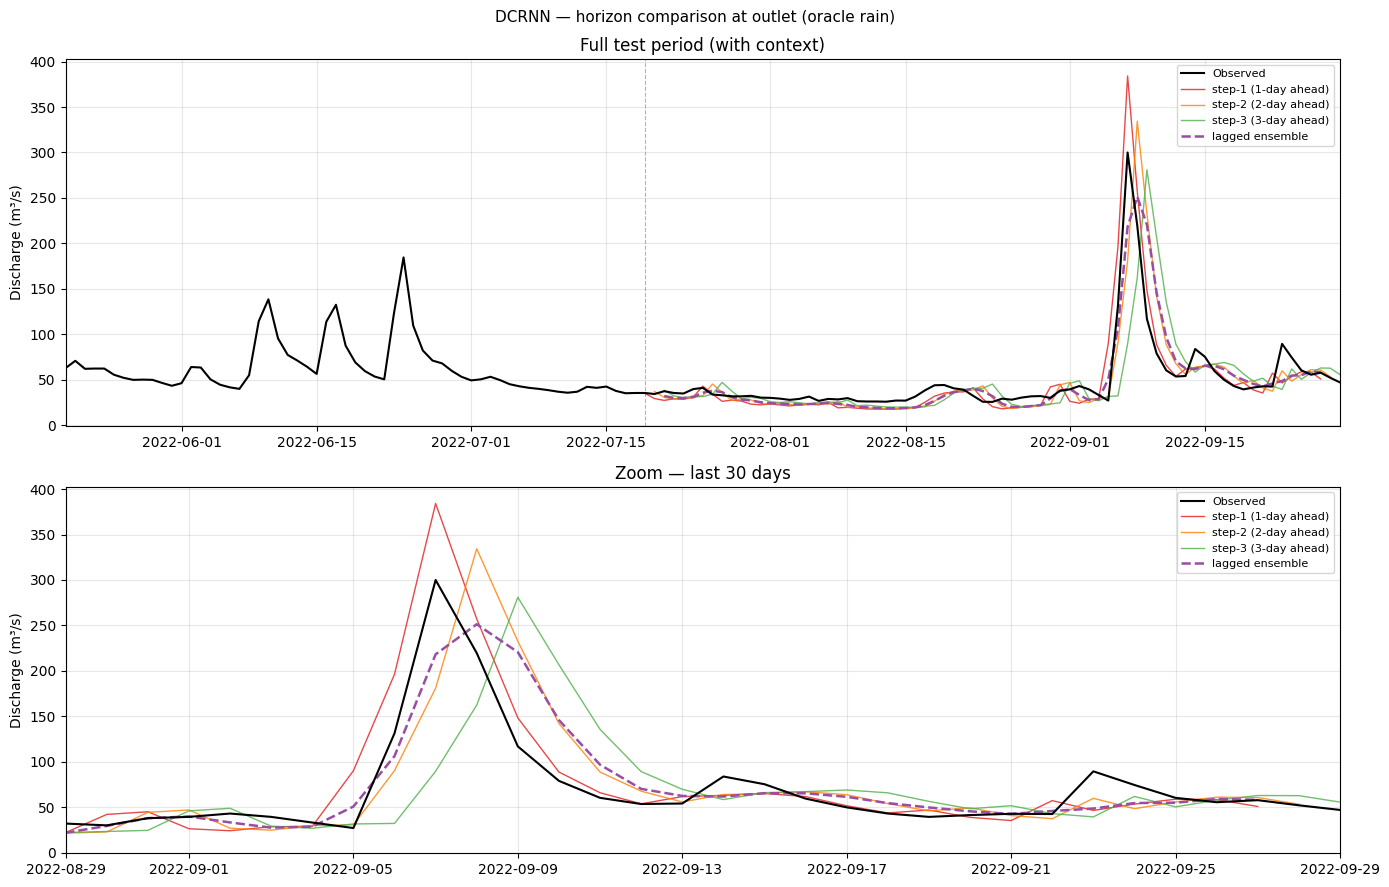


GRUGCNModel — outlet MAE by horizon (oracle rain):
  step-1:   10.241 m³/s
  step-2:   13.916 m³/s
  step-3:   17.150 m³/s
  ensemble: 13.080 m³/s


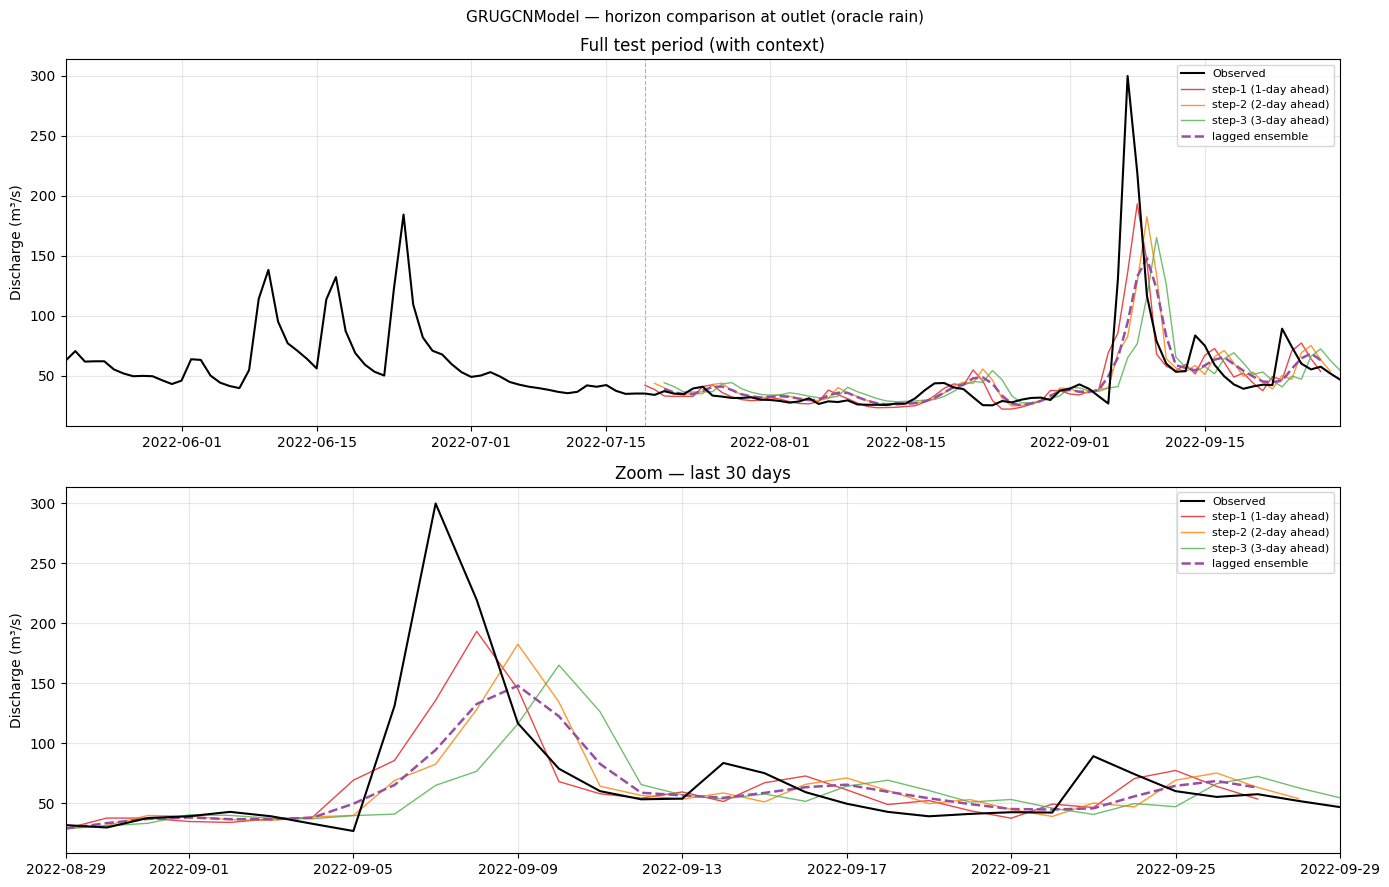

In [23]:
NODE = OUTLET_NODE

H_STYLES = {
    'step-1 (1-day ahead)': dict(color='#e41a1c', lw=1.0, alpha=0.8, ls='-'),
    'step-2 (2-day ahead)': dict(color='#ff7f00', lw=1.0, alpha=0.8, ls='-'),
    'step-3 (3-day ahead)': dict(color='#4daf4a', lw=1.0, alpha=0.8, ls='-'),
    'lagged ensemble':       dict(color='#984ea3', lw=1.8, alpha=1.0, ls='--'),
}

for model_name, fc in all_forecasts.items():
    y_hat_h  = fc['y_hat_h']
    y_true_h = fc['y_true_h']
    dates    = fc['dates']

    d1, yh1, yt1 = dates,                       y_hat_h[:, 0, NODE], y_true_h[:, 0, NODE]
    d2, yh2, yt2 = dates + pd.Timedelta('1d'),  y_hat_h[:, 1, NODE], y_true_h[:, 1, NODE]
    d3, yh3, yt3 = dates + pd.Timedelta('2d'),  y_hat_h[:, 2, NODE], y_true_h[:, 2, NODE]

    ens_dates = dates[2:]
    ens_yh    = (y_hat_h[2:, 0, NODE] + y_hat_h[1:-1, 1, NODE] + y_hat_h[:-2, 2, NODE]) / 3
    ens_yt    = y_true_h[2:, 0, NODE]

    print(f'\n{model_name} — outlet MAE by horizon (oracle rain):')
    print(f'  step-1:   {np.abs(yh1 - yt1).mean():.3f} m³/s')
    print(f'  step-2:   {np.abs(yh2 - yt2).mean():.3f} m³/s')
    print(f'  step-3:   {np.abs(yh3 - yt3).mean():.3f} m³/s')
    print(f'  ensemble: {np.abs(ens_yh - ens_yt).mean():.3f} m³/s')

    obs = target.loc[
        dates[0] - pd.Timedelta(days=CONTEXT_DAYS_OUTLET) : d3[-1],
        f'site{NODE}'
    ]

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))
    fig.suptitle(f'{model_name} — horizon comparison at outlet (oracle rain)', fontsize=11)

    for ax in axes:
        ax.plot(obs.index, obs.values, color='black', lw=1.5, label='Observed', zorder=5)
        ax.plot(d1, yh1, label='step-1 (1-day ahead)', **H_STYLES['step-1 (1-day ahead)'])
        ax.plot(d2, yh2, label='step-2 (2-day ahead)', **H_STYLES['step-2 (2-day ahead)'])
        ax.plot(d3, yh3, label='step-3 (3-day ahead)', **H_STYLES['step-3 (3-day ahead)'])
        ax.plot(ens_dates, ens_yh, label='lagged ensemble', **H_STYLES['lagged ensemble'])
        ax.set_ylabel('Discharge (m³/s)')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.3)

    axes[0].set_xlim(dates[0] - pd.Timedelta(days=CONTEXT_DAYS_OUTLET), d3[-1])
    axes[0].set_title('Full test period (with context)')
    axes[0].axvline(dates[0], color='grey', ls='--', lw=0.8, alpha=0.6)
    axes[1].set_xlim(dates[-30], d3[-1])
    axes[1].set_title('Zoom — last 30 days')

    plt.tight_layout()
    plt.savefig(f'figures/horizon_comparison_{model_name}_rain_forecast_1day.png', dpi=300)
    plt.show()
